<a href="https://colab.research.google.com/github/Ripa-Shah/Big-Data-Technology/blob/main/MIS584_Lab3_Shah_Ripa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIS584 Lab Assignment 3
## Learning Objectives
* Demonstrate the understanding of **streaming data collection**
* Demonstrate the understanding of **Kafka architecture**
* Demonstrate the capability of **reading API documents for formulating API requests**

## Due Date
**Check D2L for the Due Dates**

## Assignment Submission Instructions
When your file is ready, submit the following deliverables to the Lab Assignmen 3 dropbox:
* Provide the link to your Google Colab notebook in the comments section; please make sure that **you enable the general access to your notebook with links before submission**.
* Upload the notebook file with the `.ipynb` suffix to the submission drop box. The uploaded notebook should have the same content as the one shared through the link, include enough documentation of the code, and have all the outputs available.
* Upload the CSV file that stores all the collected Wiki recent changes information you collected for Part 2 of this lab assignment.

## Others
As always, feel free to come to our office hours or let us know through email if you face any difficulties/challenges while finishing the assignment. Good luck! For your convenience, I have created the text and code cells you might need for the lab assignment. Please also complete your contact information in the notebook as well.

You will notice that, in this Lab Assignment, there are not many "empty" spaces where you need to fill your own code. Instead, the main objective is to let you explore the streaming data, Kafka environment, and API documents and successfully follow the exercises (with some parameter adjustments).

## Student's Contact Information:
Name: Ripa Shah

Email: ripashah@arizona.edu

## Part 1: Stream Data Pipeline Exercise using Apache Kafka (3.5 Points)

Please review and practice ```MIS584_Kafka_StockPrice.ipynb``` under Module 3: [https://colab.research.google.com/drive/1NUSe0Pue2UL3i3fN1SDEYcYZolXQTGya?usp=sharing](https://colab.research.google.com/drive/1NUSe0Pue2UL3i3fN1SDEYcYZolXQTGya?usp=sharing)

* Select a ticker (e.g., UBER, SBUX, etc) with your own interest, collect stock price data for the ticker, and generate moving-average plots.
  * You don't have to provide plots for every single new data points as in the lab session Colab, i.e., you may adjust the interval between the two consecutive plots.
* Modify period, interval, or other available parameters based on you preference. yfinance takes the following parameters as input:
  * **period**: data period to download (either use period parameter or use start and end) Valid periods are:
“1d”, “5d”, “1mo”, “3mo”, “6mo”, “1y”, “2y”, “5y”, “10y”, “ytd”, “max”.
  * **interval**: data interval (1m data is only for available for last 7 days, and data interval <1d for the last 60 days) Valid intervals are:
“1m”, “2m”, “5m”, “15m”, “30m”, “60m”, “90m”, “1h”, “1d”, “5d”, “1wk”, “1mo”, “3mo”.
  * **start**: If not using period - in the format (yyyy-mm-dd) or datetime.
  * **end**: If not using period - in the format (yyyy-mm-dd) or datetime.
  * Please visit the following link for details: [yfinance Library – A Complete Guide](https://algotrading101.com/learn/yfinance-guide/#:~:text=interval%3A%20data%20interval%20(1m%20data,%E2%80%9C1mo%E2%80%9D%2C%20%E2%80%9C3mo%E2%80%9D)

### Solution for Lab Assignment 3 Part 1
Please replace this sentence with the documentation of your code for Lab Assignment 3 Part 1.

In [ ]:
"""
This code cell is for Lab Assignment 3 Part 1
"""

!pip install pyspark
!pip install sseclient
!pip install kafka-python

  Preparing metadata (setup.py) ... done
  Created wheel for sseclient: filename=sseclient-0.0.27-py3-none-any.whl size=5563 sha256=08de921c635e72b85687b09583bf2dd133b130daf839dde437b05f9e2af404c7
  Stored in directory: /root/.cache/pip/wheels/31/92/90/140c622b64ef3858608d5bbceb950fc169553911f32c2eca19
Successfully built sseclient
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.8/309.8 kB 24.2 MB/s eta 0:00:00


In [ ]:
# the code below mounts your google drive to /content/drive folder
# you might need to provide authorizations using your google account
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import os
from datetime import datetime
import time
import threading
import json
import kafka
from kafka import KafkaProducer
from kafka.errors import KafkaError
import requests
from sseclient import SSEClient as EventSource

In [ ]:
# Download Apache Kafka and unzip into your Google Colab session.
!curl -sSOL https://archive.apache.org/dist/kafka/3.1.0/kafka_2.13-3.1.0.tgz
!tar -xzf kafka_2.13-3.1.0.tgz

In [ ]:
# start zookeeper server & kafka server set $KAFKA_HOME variable path in bashrc (i.e., a configuration file for the Bash shell).
!./kafka_2.13-3.1.0/bin/zookeeper-server-start.sh -daemon ./kafka_2.13-3.1.0/config/zookeeper.properties #--override delete.topic.enable=true
!./kafka_2.13-3.1.0/bin/kafka-server-start.sh -daemon ./kafka_2.13-3.1.0/config/server.properties
!echo "Waiting for 10 secs until kafka and zookeeper services are up and running"
!sleep 10

Waiting for 10 secs until kafka and zookeeper services are up and running


In [ ]:
# see if kafka properties are shown in the results.
!ps -ef | grep kafka

root        2004       1 18 03:40 ?        00:00:02 java -Xmx512M -Xms512M -server -XX:+UseG1GC -XX:MaxGCPauseMillis=20 -XX:InitiatingHeapOccupancyPercent=35 -XX:+ExplicitGCInvokesConcurrent -XX:MaxInlineLevel=15 -Djava.awt.headless=true -Xlog:gc*:file=/content/kafka_2.13-3.1.0/bin/../logs/zookeeper-gc.log:time,tags:filecount=10,filesize=100M -Dcom.sun.management.jmxremote -Dcom.sun.management.jmxremote.authenticate=false -Dcom.sun.management.jmxremote.ssl=false -Dkafka.logs.dir=/content/kafka_2.13-3.1.0/bin/../logs -Dlog4j.configuration=file:./kafka_2.13-3.1.0/bin/../config/log4j.properties -cp /content/kafka_2.13-3.1.0/bin/../libs/activation-1.1.1.jar:/content/kafka_2.13-3.1.0/bin/../libs/aopalliance-repackaged-2.6.1.jar:/content/kafka_2.13-3.1.0/bin/../libs/argparse4j-0.7.0.jar:/content/kafka_2.13-3.1.0/bin/../libs/audience-annotations-0.5.0.jar:/content/kafka_2.13-3.1.0/bin/../libs/commons-cli-1.4.jar:/content/kafka_2.13-3.1.0/bin/../libs/commons-lang3-3.8.1.jar:/content/kafka_2.13

In [ ]:
pip install yfinance pandas


In [ ]:
!pip install avro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 10.5 MB/s eta 0:00:00


In [ ]:
import time
import json
import kafka
from kafka import KafkaProducer
from kafka.errors import KafkaError
import io
import avro.schema
from avro.io import DatumWriter

In [ ]:
# create topics
# define producer
topic = 'AMAZON'
bootstrap_server = "localhost:9092"
producer = kafka.KafkaProducer(
    bootstrap_servers=[bootstrap_server]
)

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import datetime

In [ ]:

ticker = 'AMZN'
df = yf.download(tickers=ticker, period='1d', interval='5m')

/tmp/ipython-input-2262827035.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, period='1d', interval='5m')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head(100)

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Datetime,,,,,
2025-11-14 14:30:00+00:00,233.664993,235.669998,232.889999,235.119995,2930958
2025-11-14 14:35:00+00:00,235.019897,235.559998,233.304001,233.645004,684547
2025-11-14 14:40:00+00:00,234.410004,235.440002,234.345001,235.000000,421038
2025-11-14 14:45:00+00:00,234.697495,234.729996,234.070007,234.389999,556877
2025-11-14 14:50:00+00:00,235.250000,235.669998,234.610001,234.654999,481015
...,...,...,...,...,...
2025-11-14 20:35:00+00:00,235.020004,235.279999,234.880997,235.100006,343554
2025-11-14 20:40:00+00:00,234.649994,235.050003,234.649994,234.994995,360848


In [ ]:
# stock_dict = df["High"].to_dict().items()
stock_dict = df['High', 'AMZN'].to_dict().items()

In [ ]:
for keys,values in stock_dict:
    print(keys)
    print(values)

2025-11-14 14:30:00+00:00
235.6699981689453
2025-11-14 14:35:00+00:00
235.55999755859375
2025-11-14 14:40:00+00:00
235.44000244140625
2025-11-14 14:45:00+00:00
234.72999572753906
2025-11-14 14:50:00+00:00
235.6699981689453
2025-11-14 14:55:00+00:00
236.0749969482422
2025-11-14 15:00:00+00:00
235.7899932861328
2025-11-14 15:05:00+00:00
236.1300048828125
2025-11-14 15:10:00+00:00
236.22000122070312
2025-11-14 15:15:00+00:00
236.4499969482422
2025-11-14 15:20:00+00:00
236.25990295410156
2025-11-14 15:25:00+00:00
236.75
2025-11-14 15:30:00+00:00
236.89999389648438
2025-11-14 15:35:00+00:00
237.63999938964844
2025-11-14 15:40:00+00:00
237.69000244140625
2025-11-14 15:45:00+00:00
238.3300018310547
2025-11-14 15:50:00+00:00
238.47000122070312
2025-11-14 15:55:00+00:00
238.02560424804688
2025-11-14 16:00:00+00:00
238.02999877929688
2025-11-14 16:05:00+00:00
237.73190307617188
2025-11-14 16:10:00+00:00
238.00999450683594
2025-11-14 16:15:00+00:00
238.2729034423828
2025-11-14 16:20:00+00:00
238.

In [ ]:
pip install requests

In [ ]:
# With Schema

DATA_FOLDER_PATH = '/content/drive/MyDrive/ColabNotebooks/Data'

# Example: List the contents of your data folder
import os
print(os.listdir(DATA_FOLDER_PATH))
FILENAME = 'stock_schema.avsc'

# Use an f-string (f"...") to embed the variable
SCHEMA_PATH = f"{DATA_FOLDER_PATH}/{FILENAME}"

print(SCHEMA_PATH)
SCHEMA = avro.schema.parse(open(SCHEMA_PATH).read())

'''
{
	"namespace": "stock_schema.avro",
	"type": "record",
	"name": "Stock",
	"fields": [
		{"name": "name", "type": "string"},
		{"name": "time",  "type": "string"},
		{"name": "price", "type": "float"}
	]
}
'''

['mis584_float.txt', 'converted_file2.txt', 'transformed_numbers.txt', 'stock_schema.avsc', 'wikidata.csv']
/content/drive/MyDrive/ColabNotebooks/Data/stock_schema.avsc


'\n{\n\t"namespace": "stock_schema.avro",\n\t"type": "record",\n\t"name": "Stock",\n\t"fields": [\n\t\t{"name": "name", "type": "string"},\n\t\t{"name": "time",  "type": "string"},\n\t\t{"name": "price", "type": "float"}\n\t]\n}\n'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_FOLDER_PATH = '/content/drive/MyDrive/ColabNotebooks/Data'

# Example: List the contents of your data folder
import os
print(os.listdir(DATA_FOLDER_PATH))

# Example: Read a file from your data folder
# import pandas as pd
# df = pd.read_csv(f'{DATA_FOLDER_PATH}/my_data.csv')

['mis584_float.txt', 'converted_file2.txt', 'transformed_numbers.txt', 'stock_schema.avsc', 'wikidata.csv']


In [ ]:
import yfinance as yf


amazon = yf.Ticker("AMZN")

ticker = 'AMZN'
df = yf.download(tickers=ticker, period='1y', interval='1d')

df.head(100)

print(df.columns)

## In many cases, we define the functions like below to "write to kafka" for specific topics using producer.
def error_callback(exc):
    raise Exception('Error while sendig data to kafka: {0}'.format(str(exc)))

def write_to_kafka(topic_name, items):
  global count
  count=0
  producer = KafkaProducer(bootstrap_servers=['127.0.0.1:9092'])
  for message in items:

        bytes_writer = io.BytesIO()
        encoder = avro.io.BinaryEncoder(bytes_writer)

        writer = DatumWriter(SCHEMA)
        data = {
            "name": ticker,
            "time": message[0].strftime('%Y-%m-%d %H:%M:%S'),
            "price": message[1]
        }
        writer.write(data, encoder)

        raw_bytes = bytes_writer.getvalue()
        print(data, raw_bytes)
        # producer.send(topic_name)
        producer.send(topic_name, raw_bytes)
        # producer.send(topic_name, key=key.encode('utf-8'), value=message.encode('utf-8')).add_errback(error_callback)
        count+=1
  producer.flush()
  print("Wrote {0} messages into topic: {1}".format(count, topic_name))





/tmp/ipython-input-992555730.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=ticker, period='1y', interval='1d')
[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', 'AMZN'),
            (  'High', 'AMZN'),
            (   'Low', 'AMZN'),
            (  'Open', 'AMZN'),
            ('Volume', 'AMZN')],
           names=['Price', 'Ticker'])


In [ ]:
write_to_kafka(topic, stock_dict)


{'name': 'AMZN', 'time': '2025-11-14 14:30:00', 'price': 235.6699981689453} b'\x08AMZN&2025-11-14 14:30:00\x85\xabkC'


{'name': 'AMZN', 'time': '2025-11-14 14:35:00', 'price': 235.55999755859375} b'\x08AMZN&2025-11-14 14:35:00\\\x8fkC'
{'name': 'AMZN', 'time': '2025-11-14 14:40:00', 'price': 235.44000244140625} b'\x08AMZN&2025-11-14 14:40:00\xa4pkC'
{'name': 'AMZN', 'time': '2025-11-14 14:45:00', 'price': 234.72999572753906} b'\x08AMZN&2025-11-14 14:45:00\xe1\xbajC'
{'name': 'AMZN', 'time': '2025-11-14 14:50:00', 'price': 235.6699981689453} b'\x08AMZN&2025-11-14 14:50:00\x85\xabkC'
{'name': 'AMZN', 'time': '2025-11-14 14:55:00', 'price': 236.0749969482422} b'\x08AMZN&2025-11-14 14:55:003\x13lC'
{'name': 'AMZN', 'time': '2025-11-14 15:00:00', 'price': 235.7899932861328} b'\x08AMZN&2025-11-14 15:00:00=\xcakC'
{'name': 'AMZN', 'time': '2025-11-14 15:05:00', 'price': 236.1300048828125} b'\x08AMZN&2025-11-14 15:05:00H!lC'
{'name': 'AMZN', 'time': '2025-11-14 15:10:00', 'price': 236.22000122070312} b'\x08AMZN&2025-11-14 15:10:00R8lC'
{'name': 'AMZN', 'time': '2025-11-14 15:15:00', 'price': 236.4499969482422}

Moving Averages Calculated.


/tmp/ipython-input-106011225.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
/tmp/ipython-input-106011225.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_prices[f'{SMA_SHORT_WINDOW}h_SMA'] = close_prices['Close'].rolling(window=SMA_SHORT_WINDOW).mean()
/tmp/ipython-input-106011225.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_prices[f'{SMA_LONG_WINDOW}h_SMA'] = close_prices['Close'].rolling(window=SMA_LONG_WINDOW).mean()


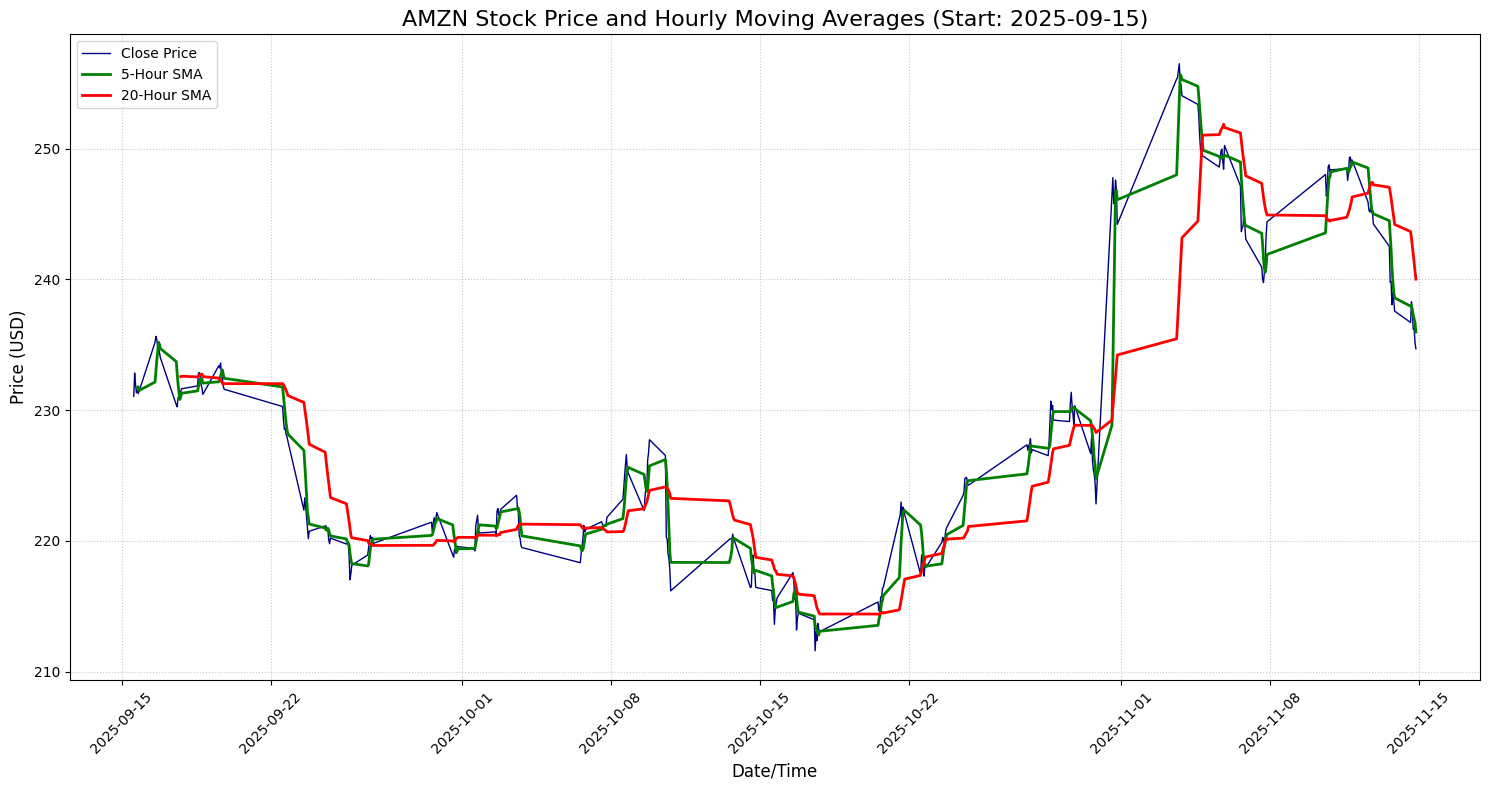


Successfully generated plot for AMZN with 1h data.


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Configuration: Ticker and yfinance Parameters ---
ticker_symbol = "AMZN"
interval_selection = "1h"
start_date = "2025-09-15"
end_date = None # Defaults to the current date

# Moving Average Periods (in hours/periods)
SMA_SHORT_WINDOW = 5
SMA_LONG_WINDOW = 20

# --- 2. Collect Stock Price Data ---
print(f"Downloading {ticker_symbol} data: {start_date} to today (Interval: {interval_selection})...")

try:
    # Download the historical data using start and end dates instead of 'period'
    data = yf.download(
        ticker_symbol,
        start=start_date,
        interval=interval_selection,
        progress=False)
    if data.empty:
        print("Error: No data retrieved. Check the ticker symbol and date/interval constraints.")
    else:
        # Keep only the 'Close' price
        close_prices = data[['Close']]

        # --- 3. Calculate Moving Averages (Simple Moving Average - SMA) ---
        close_prices[f'{SMA_SHORT_WINDOW}h_SMA'] = close_prices['Close'].rolling(window=SMA_SHORT_WINDOW).mean()
        close_prices[f'{SMA_LONG_WINDOW}h_SMA'] = close_prices['Close'].rolling(window=SMA_LONG_WINDOW).mean()

        print("Moving Averages Calculated.")

        # --- 4. Generate Moving-Average Plot ---
        plt.figure(figsize=(15, 8))

        # Plot the original Close Price
        plt.plot(close_prices['Close'], label='Close Price', color='navy', linewidth=1.0)

        # Plot the Moving Averages
        plt.plot(close_prices[f'{SMA_SHORT_WINDOW}h_SMA'], label=f'{SMA_SHORT_WINDOW}-Hour SMA', color='green', linewidth=2.0)
        plt.plot(close_prices[f'{SMA_LONG_WINDOW}h_SMA'], label=f'{SMA_LONG_WINDOW}-Hour SMA', color='red', linewidth=2.0)

        # Set plot title and labels
        plt.title(f'{ticker_symbol} Stock Price and Hourly Moving Averages (Start: {start_date})', fontsize=16)
        plt.xlabel('Date/Time', fontsize=12)
        plt.ylabel('Price (USD)', fontsize=12)

        # Add legend and grid
        plt.legend(loc='upper left')
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.xticks(rotation=45) # Rotate x-axis labels for better visibility
        plt.tight_layout() # Adjust plot to fit rotated labels

        # Display the plot
        plt.show()

        print(f"\nSuccessfully generated plot for {ticker_symbol} with {interval_selection} data.")

except Exception as e:
    print(f"An error occurred during data processing: {e}")

## Part 2: Streaming Data and Kafka: Data Storage and Visualization (3.5 Points)

Please go through and practice ```MIS584_StreamingData_and_Kafka.ipynb``` under Module 3: [https://colab.research.google.com/drive/1arGNR58NPUFgKmk4fUTwjsyQaSXKPOhV?usp=sharing](https://colab.research.google.com/drive/1arGNR58NPUFgKmk4fUTwjsyQaSXKPOhV?usp=sharing)

* Click the following link to explore how the Wikipedia "recent changes" streaming data looks like (scrolling down to the end is challenging as the velocity of new data is high!): [https://stream.wikimedia.org/v2/stream/recentchange](https://stream.wikimedia.org/v2/stream/recentchange)
* To simulate an application generating events for Kafka, this simple Python producer application is created that reads events from Wikipedia and sends them to the wiki-changes Kafka topic.
  * This Colab exercise (1) saves the collected streaming data into a CSV file and (2) generates a sorted bar plot of Top 20 Users who have modified Wikipedia pages most frequently during the streaming duration of 30 seconds.
* Similarly, your tasks are to
  * (1) save the collected data into a CSV file, just like the example in the instruction.
  * (2) define your own ```streaming_duration```, select your own fields of interest (e.g., ```server_name```, ```bot```, etc.) and tabulate/plot the summary of collected data.
  * Explore [Wikimedia EventStreams API](https://stream.wikimedia.org/?doc#/streams), [MediaWiki Manual:RCFeed](https://www.mediawiki.org/wiki/Manual:RCFeed), and other links provided in the Colab for details.
  * This is an open-ended question, so please feel free to experiment with different ways!





### Solution for Lab Assignment 3 Part 2
Please replace this sentence with the documentation of your code for Lab Assignment 3 Part 2.

***You may create a separate ipynb file if that's more convenient because of conflicts in SparkContext, Producer, Consumer, etc. of Part 1.***

In [ ]:
print(os.listdir('/content/drive/MyDrive'))

['Homework 01  Due: February 20, 2021, 11:59PM.gdoc', 'Untitled document (20).gdoc', 'Untitled document (19).gdoc', 'Research Topic_Description .pdf', 'Research Topic_Description Copy from 10:00 AM .docx', 'homework 3.gdoc', 'ECE524Sp22(1).docx', 'ECE524Sp22-5-5-22-main.docx', 'Untitled document (18).gdoc', 'Research_Topic-SSRF_Attack_on_DVWA.pdf', 'Untitled document (17).gdoc', 'Untitled document (16).gdoc', 'Civil discourse.gdoc', 'Untitled document (15).gdoc', 'Untitled document (14).gdoc', 'Copy of Midterm Exam Study Guide.gdoc', 'Untitled document (13).gdoc', 'Privacy importance and Risks: AI in different industries.gdoc', 'Villa_Campana_Lease_Agreement_-__105.pdf', 'CustomerChurn1.csv', 'Week4 Assignment Step1.gdoc', 'Data warehousing Project.gdoc', 'Module Week: 5 - Week of September 19, 2022.gdoc', 'Week6_Assignment_Part1_Shah.gdoc', 'Week7_Assignment_Shah.docx', 'supermarket_sales - Sheet1.csv', '36100227-eng.zip', 'archive(1)', 'archive(2)', 'archive(3)', 'archive', 'blobfile

In [ ]:
"""
This code cell is for Lab Assignment 3 Part 2
"""

# create topics
# define producer
topic = 'wiki-changes'
bootstrap_server = "localhost:9092"

#pip install kafka-python requests pandas matplotlib

import requests
import json
import time
from kafka import KafkaProducer


# Initialize Kafka Producer
producer = KafkaProducer(
    bootstrap_servers=[bootstrap_server],
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)



print(f"Starting Wikipedia Producer for topic '{topic}'...")

#################################
# Read streaming event
#################################
# Caution: Rerun this cell if change_userlist.append doesn't show any results!

streaming_duration = 30  # Modify this value for longer/shorter streaming duration.
start_time = time.time()

# Create a new csv file to store the streaming data.

print(os.listdir('/content/drive/MyDrive'))
DATA_FOLDER_PATH = '/content/drive/MyDrive/ColabNotebooks/Data'

# Example: List the contents of your data folder
import os
print(os.listdir(DATA_FOLDER_PATH))
FILENAME = 'wikidata.csv'
FULL_FILE_PATH = f"{DATA_FOLDER_PATH}/{FILENAME}"
f = open(FULL_FILE_PATH, 'w')
f.write('{},{},{},{},{},{}\n'.format(                         # write csv headers to the file
    'server_name', 'type', 'user', 'title','timestamp','comment'))
f.close()

# headers to avoid 403
# Change Email to Yours!

HEADERS = {
    "User-Agent": "MIS584-StreamClient/1.0 (ripashah@arizona.edu)",
    "Accept": "text/event-stream",
}

streaming_url = 'https://stream.wikimedia.org/v2/stream/recentchange'

### You may choose an alternative stream (works, but schema differs from recentchange)
# streaming_url = "https://stream.wikimedia.org/v2/stream/revision-create"
# streaming_url = https://stream.wikimedia.org/v2/stream/page-create
# streaming_url = https://stream.wikimedia.org/v2/stream/page-delete

try:
    for event in EventSource(streaming_url, headers=HEADERS):
      now_time = time.time()

      if now_time - start_time > streaming_duration:      # check if data streaming needs to end
        print(end='\n'*2)
        print("Streaming ended.", end='\n'*2)
        producer.flush()
        # # producer.close()
        break

      if event.event == 'message':
          try:
              change = json.loads(event.data)             # convert json line into dictionary
          except ValueError:
              pass
          else:
              #Send msg to topic wiki-changes
              topic = 'wiki-changes'
              producer.send(topic, change)

              ################
              # OPTIONAL: you may filter where recentchange event.server_name == server_name_filter, e.g.,
              # server_name_filter = 'en.wikipedia.org'
              # Adjust indentation to equip with the following "if" statement.
              # if change['server_name'] == server_name_filter:

              type_filter = 'edit'
              #store Wiki recent change stream data
              wiki_data = {
                    'server_name': change['server_name'],
                    'type': change['type'],
                    'user': change['user'],
                    'title': change['title'],
                    'bot': change['bot'],
                    'timestamp': change['timestamp'],
                    'namespace': change['namespace'],
                    'comment': change['comment'],
                    'bot': change['bot'],
                    'server_url': change['server_url'],
                    'server_script_path': change['server_script_path'],
                    'wiki': change['wiki'],
                    'parsedcomment': change['parsedcomment'],
                    'meta': {
                        'domain': change['meta']['domain'],
                        'dt': change['meta']['dt'],
                        'id': change['meta']['id'],},
                    'offset': change['meta']['offset'],
                    'partition': change['meta']['partition'],
                    'request_id': change['meta']['request_id'],
                    'stream': change['meta']['stream'],
              }
              #print user and title edited
              # print('{user} edited {title}'.format(**change))

              # print streamed wiki recentchange
              print(wiki_data)

              f = open(FULL_FILE_PATH, 'a') # Change it to your path.
              # Sanitize the comment field before writing
              sanitized_comment = wiki_data['comment'].replace('"', '""')
              f.write('{},{},{},{},{},"{}"\n'.format(               # append wiki recent change data to the csv file
              wiki_data['server_name'],
              wiki_data['type'],
              wiki_data['user'],
              wiki_data['title'],
              wiki_data['timestamp'],
              #wiki_data['comment']
              sanitized_comment
              ))

except KeyboardInterrupt:
    print("process interrupted")


Starting Wikipedia Producer for topic 'wiki-changes'...
['Homework 01  Due: February 20, 2021, 11:59PM.gdoc', 'Untitled document (20).gdoc', 'Untitled document (19).gdoc', 'Research Topic_Description .pdf', 'Research Topic_Description Copy from 10:00 AM .docx', 'homework 3.gdoc', 'ECE524Sp22(1).docx', 'ECE524Sp22-5-5-22-main.docx', 'Untitled document (18).gdoc', 'Research_Topic-SSRF_Attack_on_DVWA.pdf', 'Untitled document (17).gdoc', 'Untitled document (16).gdoc', 'Civil discourse.gdoc', 'Untitled document (15).gdoc', 'Untitled document (14).gdoc', 'Copy of Midterm Exam Study Guide.gdoc', 'Untitled document (13).gdoc', 'Privacy importance and Risks: AI in different industries.gdoc', 'Villa_Campana_Lease_Agreement_-__105.pdf', 'CustomerChurn1.csv', 'Week4 Assignment Step1.gdoc', 'Data warehousing Project.gdoc', 'Module Week: 5 - Week of September 19, 2022.gdoc', 'Week6_Assignment_Part1_Shah.gdoc', 'Week7_Assignment_Shah.docx', 'supermarket_sales - Sheet1.csv', '36100227-eng.zip', 'archi

['mis584_float.txt', 'converted_file2.txt', 'transformed_numbers.txt', 'stock_schema.avsc', 'wikidata.csv']
Successfully loaded data with Latin-1 encoding.
               server_name  type            user  \
0         fr.wikipedia.org  edit  WikiCleanerBot   
1         www.wikidata.org  edit        MatSuBot   
2         www.wikidata.org  edit             Xyb   
3         en.wikipedia.org  edit     Legofan3484   
4         ja.wikipedia.org   new    æèæ´å¤©   
..                     ...   ...             ...   
597       vi.wikipedia.org   log       Ladsgroup   
598       www.wikidata.org  edit        MatSuBot   
599       ru.wikiquote.org   log         QBA-bot   
600  commons.wikimedia.org  edit      Rkieferbot   
601  commons.wikimedia.org  edit   SchlurcherBot   

                                                 title   timestamp  \
0            Ãlections municipales de 2026 Ã  Roubaix  1763352732   
1                                             Q5674679  1763352734   
2        

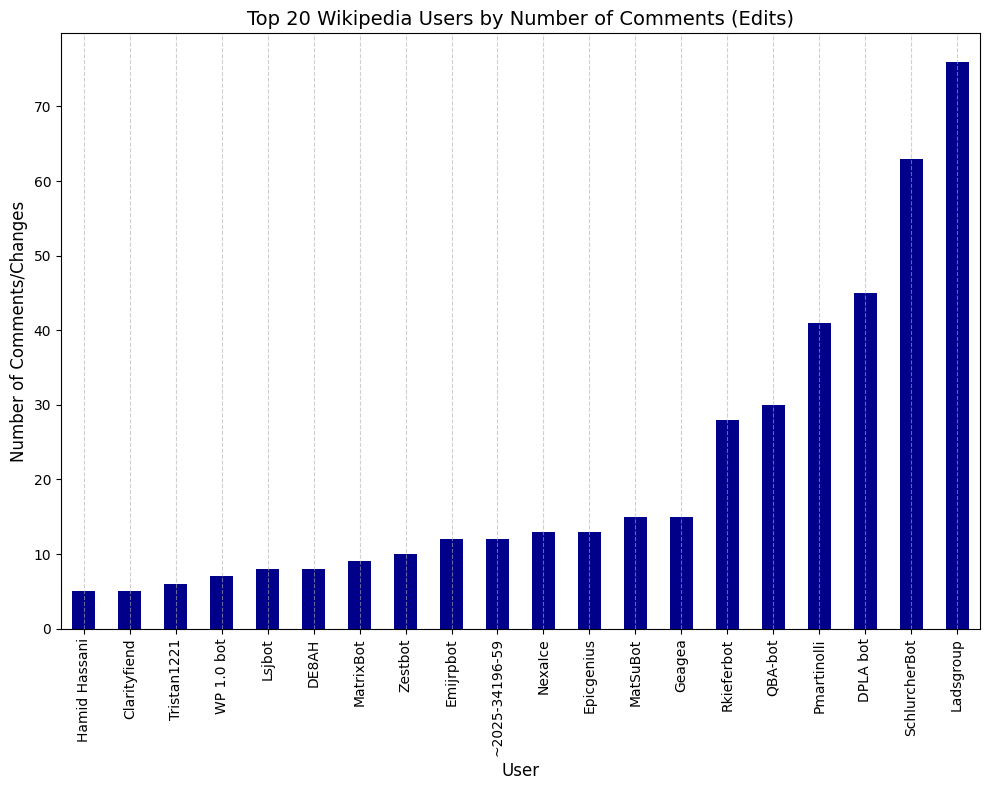

In [ ]:
#create a bar plot for above csv file
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER_PATH = '/content/drive/MyDrive/ColabNotebooks/Data'

# Example: List the contents of your data folder
import os
print(os.listdir(DATA_FOLDER_PATH))
FILENAME = 'wikidata.csv'
FULL_FILE_PATH = f"{DATA_FOLDER_PATH}/{FILENAME}"

#CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/wikidata.csv'

try:
    # Try the most likely common alternative encoding
    df = pd.read_csv(FULL_FILE_PATH, encoding='latin-1',on_bad_lines='skip' )
    print("Successfully loaded data with Latin-1 encoding.")
except UnicodeDecodeError:
    # If Latin-1 fails, try the Windows encoding
    df = pd.read_csv(FULL_FILE_PATH, encoding='cp1252')
    print("Successfully loaded data with CP1252 encoding.")
except Exception as e:
    print(f"Error loading file: {e}")
print(df)
df.dropna(subset=['user'], inplace=True)
user_counts_groupby = df.groupby('user')['comment'].count().sort_values(ascending=False).head(20)
print('Number of comments per user:')
print(user_counts_groupby)

print("Generating bar chart for top 20 users...")
TOP_N = 20
# Set up the figure size
plt.figure(figsize=(10, 8))
user_counts_groupby.sort_values(ascending=True).plot(
        kind='bar',
        color='darkblue'
    )
# Set the title and labels
plt.title(f'Top {TOP_N} Wikipedia Users by Number of Comments (Edits)', fontsize=14)
plt.ylabel('Number of Comments/Changes', fontsize=12)
plt.xlabel('User', fontsize=12)

    # Add grid lines for easier comparison of bar lengths
plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Adjust layout to prevent labels from being cut off
plt.tight_layout()

    # Display the plot
plt.show()
